# Notebook 31

# Experiment 3

## Advanced Feature Engineering

Objective

Design new temporal and behavioral features to better distinguish DROWSY and NORMAL driving behaviors.

In [14]:
import os
import numpy as np
import pandas as pd

from scipy.stats import skew
from scipy.stats import kurtosis


In [15]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
dataset_path = "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/raw/UAH-DRIVESET-v1"

print(dataset_path)

/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/raw/UAH-DRIVESET-v1


In [17]:
def load_accelerometer(acc_path):

    acc_columns = [

        "timestamp",
        "active",

        "acc_x",
        "acc_y",
        "acc_z",

        "acc_x_kf",
        "acc_y_kf",
        "acc_z_kf",

        "roll",
        "pitch",
        "yaw"

    ]

    acc_df = pd.read_csv(
        acc_path,
        sep=r"\s+",
        header=None,
        names=acc_columns
    )

    return acc_df

def load_gps(gps_path):

    gps_columns = [

        "timestamp",
        "speed",
        "latitude",
        "longitude",
        "altitude",

        "gps_quality",
        "satellites",

        "heading",

        "extra_1",
        "extra_2",
        "extra_3",
        "extra_4"

    ]

    gps_df = pd.read_csv(
        gps_path,
        sep=r"\s+",
        header=None,
        names=gps_columns
    )

    return gps_df
def load_lane_detection(lane_path):

    lane_df = pd.read_csv(
        lane_path,
        sep=r"\s+",
        header=None
    )

    lane_df.columns = [

        "time",

        "lane_offset",

        "phi",

        "road_width",

        "lane_state"
    ]

    return lane_df

def clean_lane_detection(lane_df):

    lane_df = lane_df.copy()

    lane_df.replace(-9, np.nan, inplace=True)

    lane_df.replace(-99, np.nan, inplace=True)

    lane_df = lane_df.sort_values(
        "time"
    )

    lane_df = lane_df.reset_index(
        drop=True
    )

    return lane_df
def load_vehicle_detection(vehicle_path):

    vehicle_df = pd.read_csv(

        vehicle_path,

        sep=r"\s+",

        header=None

    )

    vehicle_df.columns = [

        "time",

        "front_distance",

        "relative_speed",

        "vehicle_state",

        "confidence"

    ]

    return vehicle_df

In [25]:
def synchronize_sensors(acc_df, gps_df):

    master_df = pd.merge_asof(

        acc_df.sort_values("timestamp"),

        gps_df.sort_values("timestamp"),

        on="timestamp",

        direction="nearest"

    )

    return master_df

def merge_lane_data(master_df, lane_df):

    master_df = master_df.copy()
    lane_df = lane_df.copy()

    master_df = master_df.sort_values(
        "timestamp"
    )

    lane_df = lane_df.sort_values(
        "time"
    )

    merged_df = pd.merge_asof(

        master_df,

        lane_df,

        left_on="timestamp",

        right_on="time",

        direction="nearest"

    )

    merged_df.drop(
        columns=["time"],
        inplace=True
    )

    return merged_df

def merge_vehicle_data(master_df, vehicle_df):

    master_df = master_df.copy()
    vehicle_df = vehicle_df.copy()

    master_df = master_df.sort_values(
        "timestamp"
    )

    vehicle_df = vehicle_df.sort_values(
        "time"
    )

    merged_df = pd.merge_asof(

        master_df,

        vehicle_df,

        left_on="timestamp",

        right_on="time",

        direction="nearest"

    )

    merged_df.drop(
        columns=["time"],
        inplace=True
    )

    return merged_df

def clean_vehicle_detection(vehicle_df):

    vehicle_df = vehicle_df.copy()

    vehicle_df = vehicle_df.sort_values(

        "time"

    )

    vehicle_df = vehicle_df.reset_index(

        drop=True

    )

    return vehicle_df

In [41]:
def engineer_features_v6(master_df):

    master_df = master_df.copy()

    # ----------------------------------------------------
    # Acceleration Features
    # ----------------------------------------------------

    master_df["acc_resultant"] = np.sqrt(
        master_df["acc_x"]**2 +
        master_df["acc_y"]**2 +
        master_df["acc_z"]**2
    )

    master_df["acc_horizontal"] = np.sqrt(
        master_df["acc_x"]**2 +
        master_df["acc_y"]**2
    )

    master_df["acc_vertical"] = master_df["acc_z"]

    # ----------------------------------------------------
    # Delta Features
    # ----------------------------------------------------

    master_df["speed_delta"] = master_df["speed"].diff().fillna(0)

    master_df["heading_delta"] = master_df["heading"].diff().fillna(0)

    master_df["roll_delta"] = master_df["roll"].diff().fillna(0)

    master_df["pitch_delta"] = master_df["pitch"].diff().fillna(0)

    master_df["yaw_delta"] = master_df["yaw"].diff().fillna(0)

    # ----------------------------------------------------
    # Lane Features
    # ----------------------------------------------------

    master_df["lane_departure"] = (
        master_df["lane_offset"].abs() > 0.75
    ).astype(int)

    master_df["steering_alignment"] = (
        master_df["lane_offset"] *
        master_df["phi"]
    )
   # Dynamic Lane Features

    master_df["lane_offset_velocity"] = (
        master_df["lane_offset"]
        .diff()
        .fillna(0)
    )
    # ------------------------------------------------
    # Vehicle Features
    # ------------------------------------------------

    master_df["vehicle_present"] = (
        master_df["front_distance"] > 0
    ).astype(int)

    master_df["safe_distance"] = np.where(
        master_df["vehicle_present"] == 1,
        master_df["front_distance"],
        np.nan
    )

    master_df["closing_speed"] = np.where(
        master_df["vehicle_present"] == 1,
        master_df["relative_speed"],
        0
    )

    master_df["ttc"] = np.where(
        (master_df["vehicle_present"] == 1) &
        (master_df["closing_speed"] > 0),
        master_df["front_distance"] /
        master_df["closing_speed"],
        np.nan
    )
    # ---------------------------------------------
    # Dynamic Vehicle Features
    # ---------------------------------------------

    master_df["ttc_trend"] = (
        master_df["ttc"]
        .diff()
        .fillna(0)
   )

    return master_df


In [38]:
feature_df = engineer_features_v6(master_df)

feature_df[
    [
        "timestamp",
        "ttc",
        "dangerous_following"
    ]
].sample(20, random_state=42)

,timestamp,ttc,dangerous_following
691,76.61,27.222222,0
2380,247.58,26.340000,0
3066,317.15,24.611111,0
346,41.97,NaN,0
2932,303.60,26.617647,0
4417,453.94,NaN,0
5193,532.41,NaN,0
2836,293.86,27.225564,0
5388,552.07,NaN,0
1170,125.10,24.128713,0


In [39]:
print(feature_df["dangerous_following"].value_counts(dropna=False))

print()

print(feature_df["dangerous_following"].value_counts(normalize=True))

dangerous_following
0    6170
Name: count, dtype: int64

dangerous_following
0    1.0
Name: proportion, dtype: float64


In [40]:
print(feature_df["ttc"].describe())

count    4050.000000
mean       25.632981
std         2.061609
min        16.857143
25%        24.537736
50%        25.663158
75%        26.845625
max        30.588889
Name: ttc, dtype: float64


In [36]:
feature_df = engineer_features_v6(master_df)

feature_df[
    [
        "front_distance",
        "relative_speed",
        "vehicle_present",
        "safe_distance",
        "closing_speed",
        "ttc",
        "ttc_trend"
    ]
].head(20)

,front_distance,relative_speed,vehicle_present,safe_distance,closing_speed,ttc,ttc_trend
0,-1.00,-1.00,0,NaN,0.00,NaN,0.000000
1,-1.00,-1.00,0,NaN,0.00,NaN,0.000000
2,-1.00,-1.00,0,NaN,0.00,NaN,0.000000
3,17.97,0.99,1,17.97,0.99,18.151515,0.000000
4,17.97,0.99,1,17.97,0.99,18.151515,0.000000
5,18.04,1.00,1,18.04,1.00,18.040000,-0.111515
6,18.12,1.00,1,18.12,1.00,18.120000,0.080000
7,18.10,1.00,1,18.10,1.00,18.100000,-0.020000
8,18.07,1.00,1,18.07,1.00,18.070000,-0.030000
9,18.16,1.00,1,18.16,1.00,18.160000,0.090000


In [29]:
feature_df = engineer_features_v6(master_df)

feature_df[
    [
        "lane_offset",
        "lane_offset_velocity"
    ]
].head(20)

,lane_offset,lane_offset_velocity
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
5,0.0,0.0
6,0.0,0.0
7,0.0,0.0
8,0.0,0.0
9,0.0,0.0


In [30]:
feature_df[
    [
        "timestamp",
        "lane_offset",
        "lane_offset_velocity"
    ]
].sample(20, random_state=42)

,timestamp,lane_offset,lane_offset_velocity
691,76.61,0.030,0.000
2380,247.58,0.242,-0.010
3066,317.15,0.161,-0.021
346,41.97,0.081,0.000
2932,303.60,0.293,0.000
4417,453.94,0.554,-0.002
5193,532.41,-0.161,0.000
2836,293.86,0.242,-0.001
5388,552.07,0.607,-0.009
1170,125.10,0.293,0.000


In [27]:
sample_driver = "D1"

sample_trip = "20151110175712-16km-D1-NORMAL1-SECONDARY"

trip_path = os.path.join(
    dataset_path,
    sample_driver,
    sample_trip
)

acc_path = os.path.join(
    trip_path,
    "RAW_ACCELEROMETERS.txt"
)

gps_path = os.path.join(
    trip_path,
    "RAW_GPS.txt"
)

lane_path = os.path.join(
    trip_path,
    "PROC_LANE_DETECTION.txt"
)

vehicle_path = os.path.join(
    trip_path,
    "PROC_VEHICLE_DETECTION.txt"
)

In [28]:
acc_df = load_accelerometer(acc_path)

gps_df = load_gps(gps_path)

lane_df = clean_lane_detection(
    load_lane_detection(lane_path)
)

vehicle_df = clean_vehicle_detection(
    load_vehicle_detection(vehicle_path)
)

master_df = synchronize_sensors(
    acc_df,
    gps_df
)

master_df = merge_lane_data(
    master_df,
    lane_df
)

master_df = merge_vehicle_data(
    master_df,
    vehicle_df
)

print(master_df.shape)

master_df.head()

(6170, 30)


,timestamp,active,acc_x,acc_y,acc_z,acc_x_kf,acc_y_kf,acc_z_kf,roll,pitch,...,extra_3,extra_4,lane_offset,phi,road_width,lane_state,front_distance,relative_speed,vehicle_state,confidence
0,6.94,1,0.017,-0.011,0.018,-0.005,0.008,0.018,-1.523,0.015,...,0,0,0.0,-0.0,3.5,-1.0,-1.00,-1.00,0,67.4
1,7.03,1,0.046,0.007,0.019,0.016,-0.002,0.018,-1.522,0.012,...,0,0,0.0,-0.0,3.5,-1.0,-1.00,-1.00,0,67.4
2,7.14,1,0.052,-0.016,0.027,0.037,-0.005,0.018,-1.520,0.014,...,0,0,0.0,-0.0,3.5,-1.0,-1.00,-1.00,0,67.4
3,7.24,1,0.015,-0.016,0.026,0.038,-0.009,0.024,-1.523,0.014,...,0,0,0.0,-0.0,3.5,-1.0,17.97,0.99,2,65.2
4,7.34,1,-0.014,-0.017,0.040,0.012,-0.016,0.032,-1.525,0.012,...,0,0,0.0,-0.0,3.5,-1.0,17.97,0.99,2,65.2


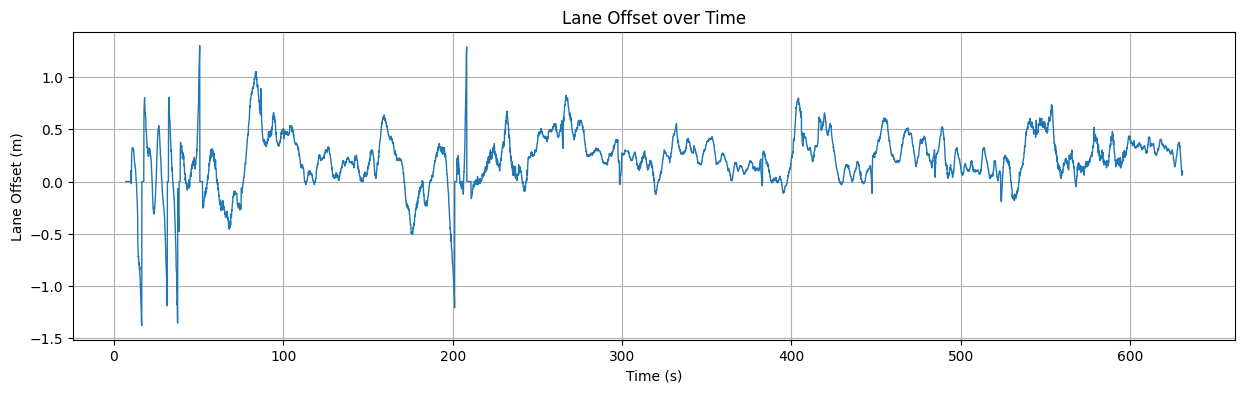

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

plt.plot(
    feature_df["timestamp"],
    feature_df["lane_offset"],
    linewidth=1
)

plt.title("Lane Offset over Time")
plt.xlabel("Time (s)")
plt.ylabel("Lane Offset (m)")
plt.grid(True)

plt.show()

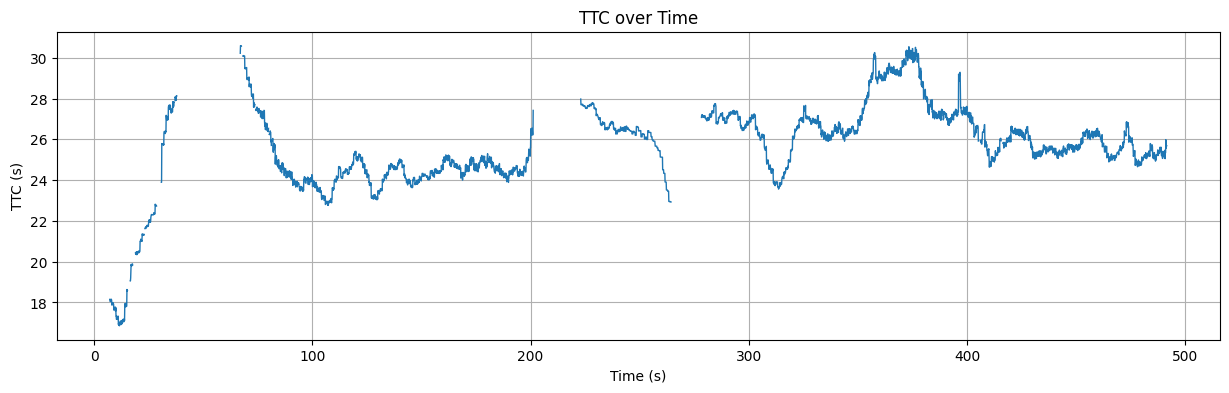

In [44]:
plt.figure(figsize=(15,4))

plt.plot(
    feature_df["timestamp"],
    feature_df["ttc"],
    linewidth=1
)

plt.title("TTC over Time")
plt.xlabel("Time (s)")
plt.ylabel("TTC (s)")
plt.grid(True)

plt.show()

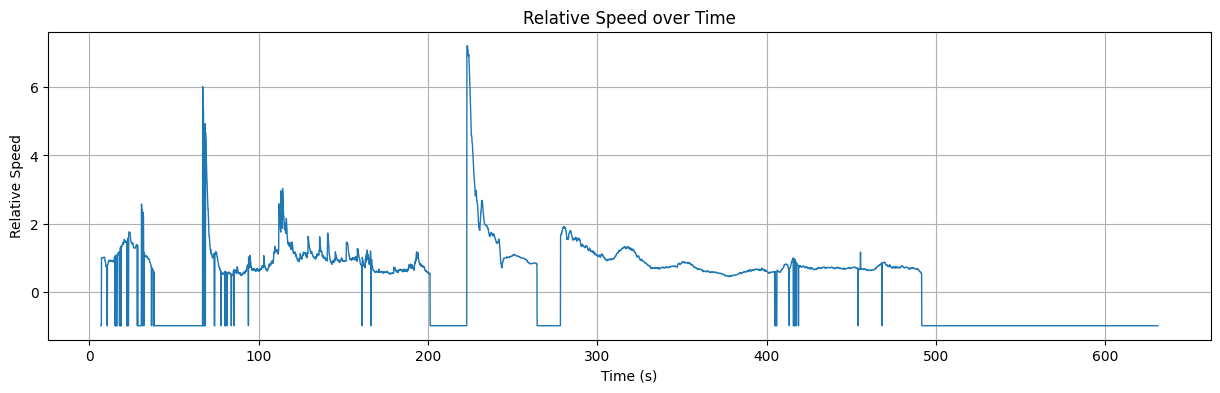

In [45]:
plt.figure(figsize=(15,4))

plt.plot(
    feature_df["timestamp"],
    feature_df["relative_speed"],
    linewidth=1
)

plt.title("Relative Speed over Time")
plt.xlabel("Time (s)")
plt.ylabel("Relative Speed")
plt.grid(True)

plt.show()

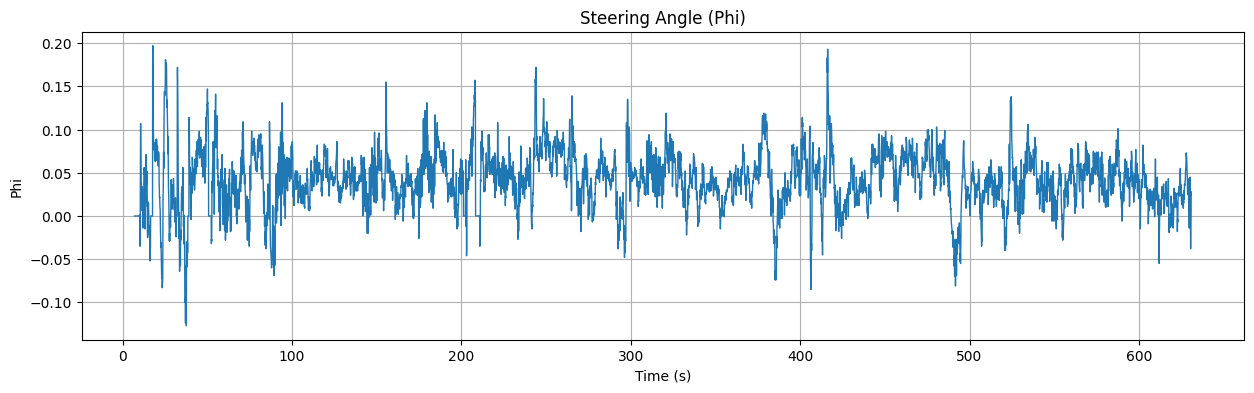

In [46]:
plt.figure(figsize=(15,4))

plt.plot(
    feature_df["timestamp"],
    feature_df["phi"],
    linewidth=1
)

plt.title("Steering Angle (Phi)")
plt.xlabel("Time (s)")
plt.ylabel("Phi")
plt.grid(True)

plt.show()

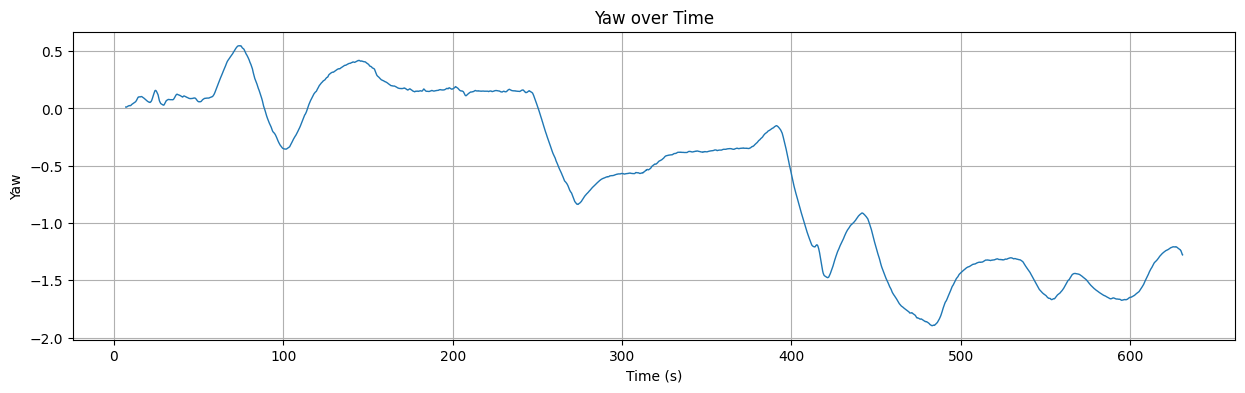

In [48]:
plt.figure(figsize=(15,4))

plt.plot(
    feature_df["timestamp"],
    feature_df["yaw"],
    linewidth=1
)

plt.title("Yaw over Time")
plt.xlabel("Time (s)")
plt.ylabel("Yaw")
plt.grid(True)

plt.show()

In [56]:
sample_driver = "D3"

sample_trip = "20151126132013-17km-D3-DROWSY-SECONDARY"
trip_path = os.path.join(
    dataset_path,
    sample_driver,
    sample_trip
)

acc_path = os.path.join(
    trip_path,
    "RAW_ACCELEROMETERS.txt"
)

gps_path = os.path.join(
    trip_path,
    "RAW_GPS.txt"
)

lane_path = os.path.join(
    trip_path,
    "PROC_LANE_DETECTION.txt"
)

vehicle_path = os.path.join(
    trip_path,
    "PROC_VEHICLE_DETECTION.txt"
)
trip_path = os.path.join(
    dataset_path,
    sample_driver,
    sample_trip
)

acc_path = os.path.join(
    trip_path,
    "RAW_ACCELEROMETERS.txt"
)

gps_path = os.path.join(
    trip_path,
    "RAW_GPS.txt"
)

lane_path = os.path.join(
    trip_path,
    "PROC_LANE_DETECTION.txt"
)

vehicle_path = os.path.join(
    trip_path,
    "PROC_VEHICLE_DETECTION.txt"
)

In [55]:
print(os.listdir(os.path.join(dataset_path, "D3")))

['20151126134736-26km-D3-AGGRESSIVE-MOTORWAY', '20151126132013-17km-D3-DROWSY-SECONDARY', '20151126130707-16km-D3-AGGRESSIVE-SECONDARY', '20151126113754-26km-D3-DROWSY-MOTORWAY', '20151126125458-16km-D3-NORMAL2-SECONDARY', '20151126124208-16km-D3-NORMAL1-SECONDARY', '20151126110502-26km-D3-NORMAL-MOTORWAY']


In [57]:
acc_df = load_accelerometer(acc_path)

gps_df = load_gps(gps_path)

lane_df = clean_lane_detection(
    load_lane_detection(lane_path)
)

vehicle_df = clean_vehicle_detection(
    load_vehicle_detection(vehicle_path)
)

master_df = synchronize_sensors(
    acc_df,
    gps_df
)

master_df = merge_lane_data(
    master_df,
    lane_df
)

master_df = merge_vehicle_data(
    master_df,
    vehicle_df
)

print(master_df.shape)

master_df.head()

(6626, 30)


,timestamp,active,acc_x,acc_y,acc_z,acc_x_kf,acc_y_kf,acc_z_kf,roll,pitch,...,extra_3,extra_4,lane_offset,phi,road_width,lane_state,front_distance,relative_speed,vehicle_state,confidence
0,0.97,0,-0.106,-0.049,0.089,-0.059,-0.029,0.052,-1.636,0.023,...,0,0,0.0,-0.0,3.5,-1,-1.0,-1.0,0,53.8
1,0.97,0,-0.059,-0.042,0.070,-0.011,-0.007,0.012,-1.472,0.020,...,0,0,0.0,-0.0,3.5,-1,-1.0,-1.0,0,53.8
2,0.97,0,-0.106,-0.049,0.089,-0.103,-0.048,0.087,-1.636,0.023,...,0,0,0.0,-0.0,3.5,-1,-1.0,-1.0,0,53.8
3,0.97,0,-0.106,-0.049,0.089,-0.099,-0.046,0.084,-1.636,0.023,...,0,0,0.0,-0.0,3.5,-1,-1.0,-1.0,0,53.8
4,0.97,0,-0.106,-0.049,0.089,-0.088,-0.041,0.075,-1.636,0.023,...,0,0,0.0,-0.0,3.5,-1,-1.0,-1.0,0,53.8


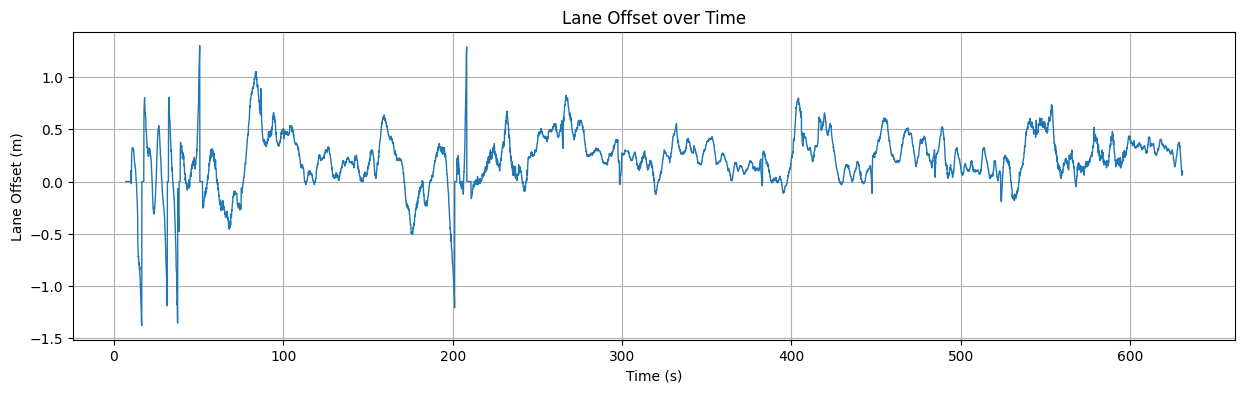

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

plt.plot(
    feature_df["timestamp"],
    feature_df["lane_offset"],
    linewidth=1
)

plt.title("Lane Offset over Time")
plt.xlabel("Time (s)")
plt.ylabel("Lane Offset (m)")
plt.grid(True)

plt.show()

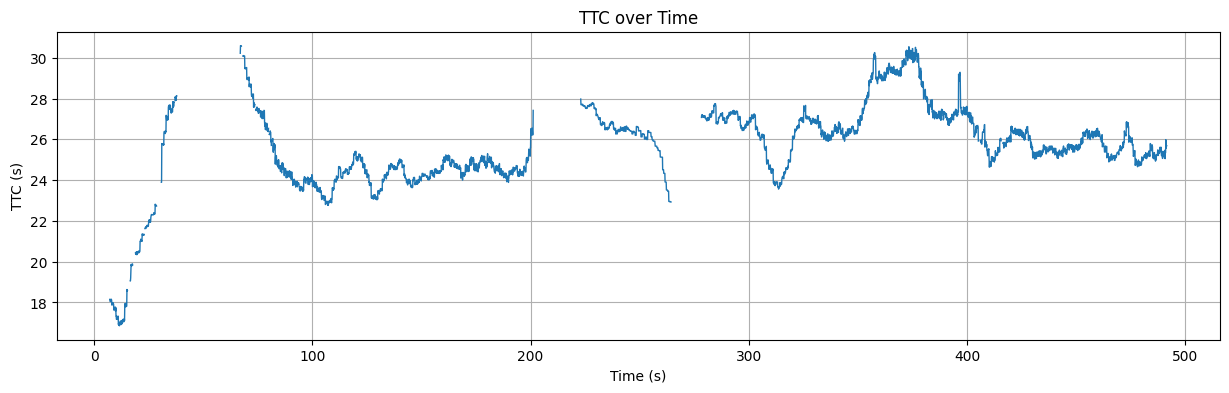

In [59]:
plt.figure(figsize=(15,4))

plt.plot(
    feature_df["timestamp"],
    feature_df["ttc"],
    linewidth=1
)

plt.title("TTC over Time")
plt.xlabel("Time (s)")
plt.ylabel("TTC (s)")
plt.grid(True)

plt.show()

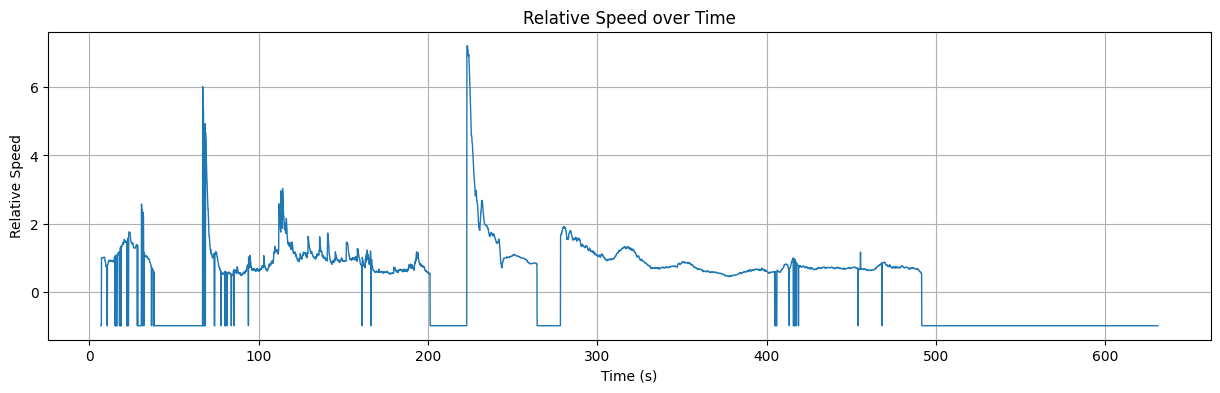

In [60]:
plt.figure(figsize=(15,4))

plt.plot(
    feature_df["timestamp"],
    feature_df["relative_speed"],
    linewidth=1
)

plt.title("Relative Speed over Time")
plt.xlabel("Time (s)")
plt.ylabel("Relative Speed")
plt.grid(True)

plt.show()

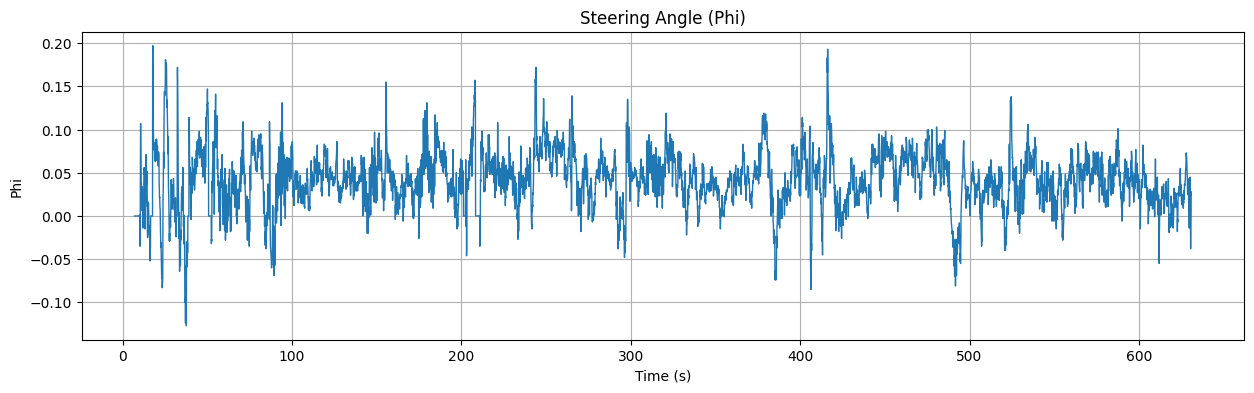

In [61]:
plt.figure(figsize=(15,4))

plt.plot(
    feature_df["timestamp"],
    feature_df["phi"],
    linewidth=1
)

plt.title("Steering Angle (Phi)")
plt.xlabel("Time (s)")
plt.ylabel("Phi")
plt.grid(True)

plt.show()

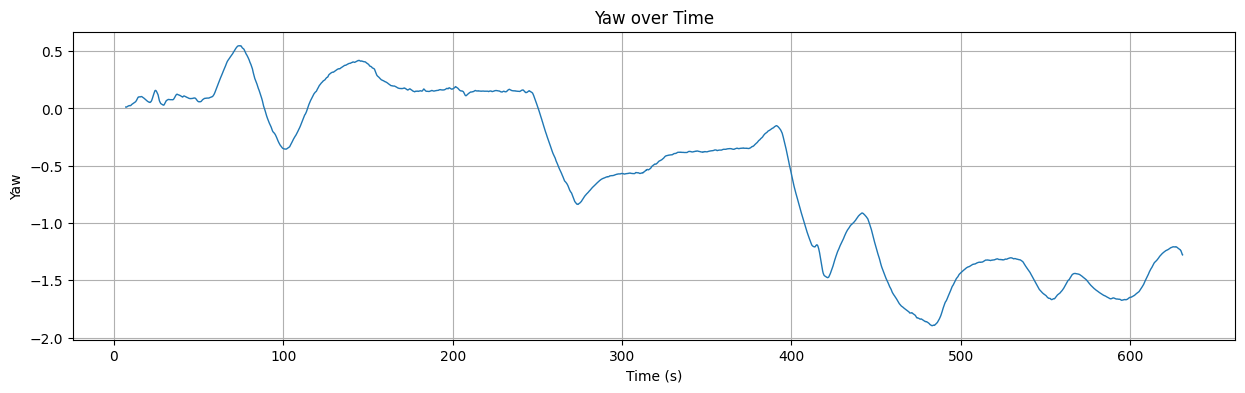

In [62]:
plt.figure(figsize=(15,4))

plt.plot(
    feature_df["timestamp"],
    feature_df["yaw"],
    linewidth=1
)

plt.title("Yaw over Time")
plt.xlabel("Time (s)")
plt.ylabel("Yaw")
plt.grid(True)

plt.show()

In [63]:
print(sample_driver)
print(sample_trip)

print()

print(trip_path)

D3
20151126132013-17km-D3-DROWSY-SECONDARY

/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/raw/UAH-DRIVESET-v1/D3/20151126132013-17km-D3-DROWSY-SECONDARY


In [64]:
print(master_df.shape)

print(feature_df.shape)

print(feature_df["timestamp"].min())
print(feature_df["timestamp"].max())

(6626, 30)
(6170, 47)
6.94
630.94
